In [2]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries Successfully Imported')

Libraries Successfully Imported


In [3]:
#Read the dataset into pandas dataframe
df=pd.read_csv(r"C:\Users\User\Downloads\archive (1)\Housing.csv")

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [7]:
df.shape

(545, 13)

In [4]:
#Get the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
#statistics review of the dataset
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Preprocessing of Data

In [10]:
#Check for any missing value 
df.isnull().sum().sort_values(ascending=True)
#No missing value(s)


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
#Check for duplicate(s) and unique values
df.duplicated().sum()


np.int64(0)

In [12]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

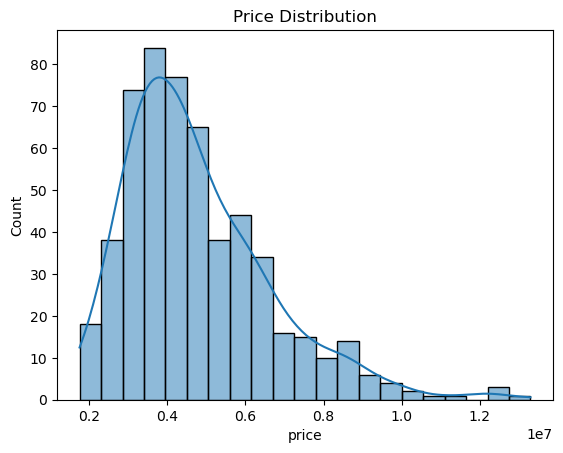

In [13]:
sns.histplot(x='price', data=df, kde=True)
plt.title('Price Distribution')
plt.show()

In [14]:
#Histoplot for Areas, to see the distribution

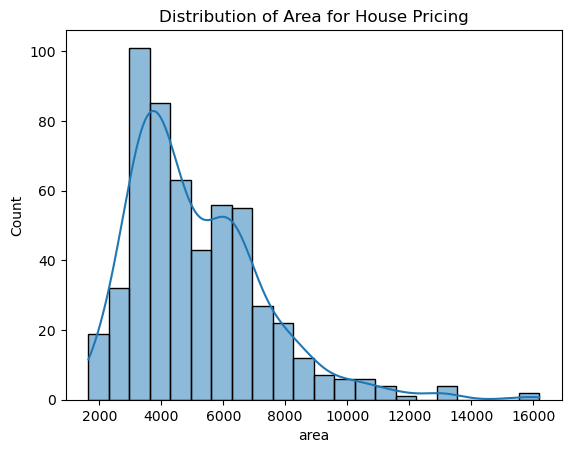

In [15]:
sns.histplot(df['area'],kde=True)
plt.title('Distribution of Area for House Pricing')
plt.show()

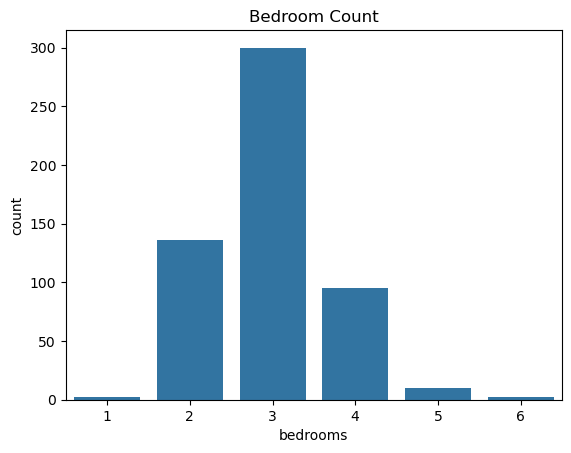

In [16]:
sns.countplot(x='bedrooms',data=df)
plt.title('Bedroom Count')
plt.show()

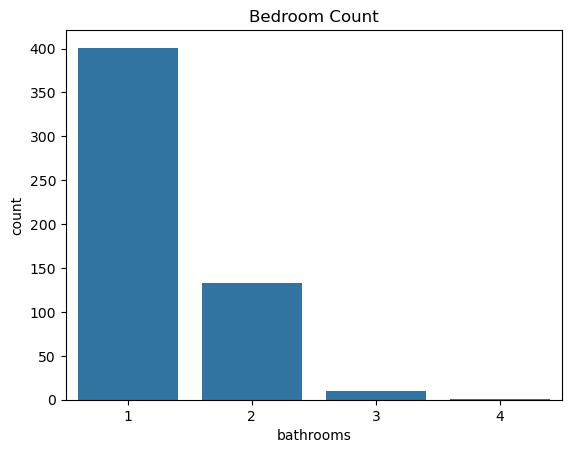

In [17]:
sns.countplot(x='bathrooms',data=df)
plt.title('Bedroom Count')
plt.show()

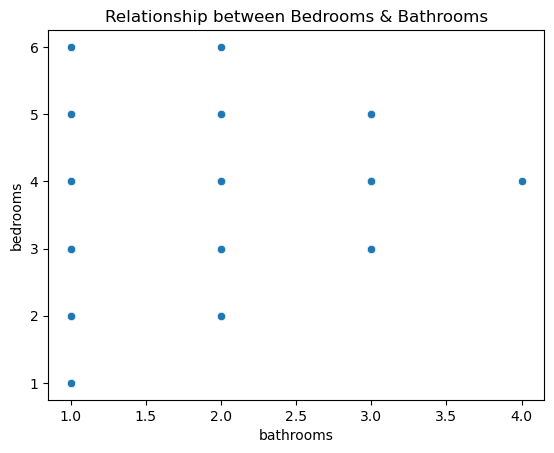

In [18]:
sns.scatterplot(x='bathrooms', y='bedrooms', data=df)
plt.title('Relationship between Bedrooms & Bathrooms')
plt.show()

In [19]:
pd.crosstab(df['bedrooms'], df['bathrooms'])

bathrooms,1,2,3,4
bedrooms,,,,
1,2,0,0,0
2,128,8,0,0
3,224,72,4,0
4,42,48,4,1
5,4,4,2,0
6,1,1,0,0


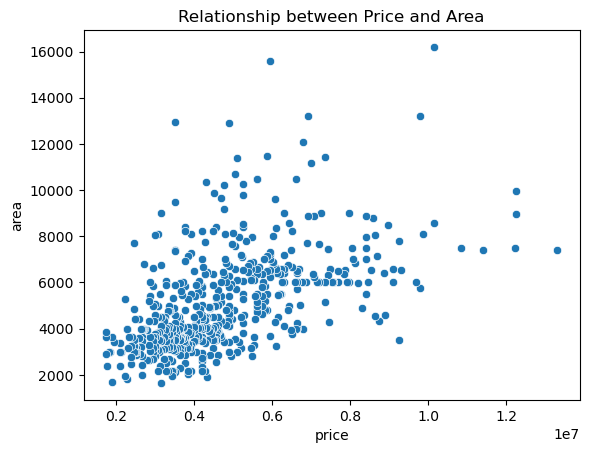

In [20]:
sns.scatterplot(x='price', y='area', data=df)
plt.title('Relationship between Price and Area')
plt.show()

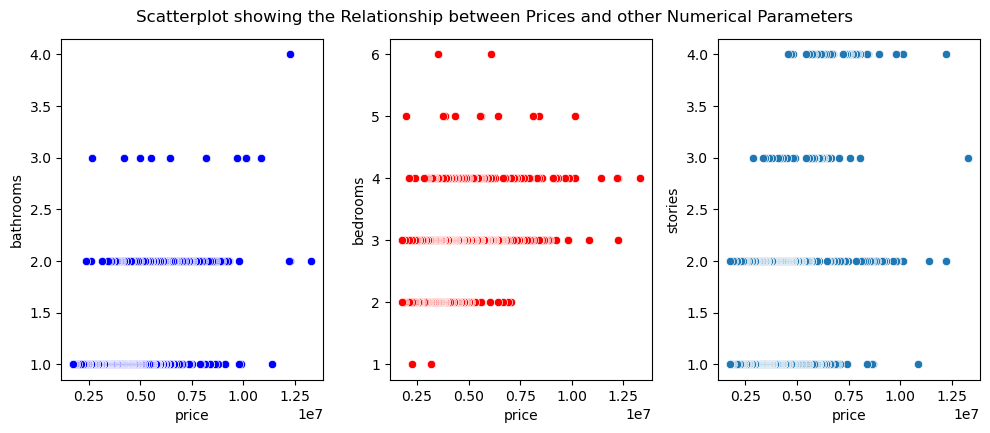

In [28]:
fig=plt.figure(figsize=(10,8))

plt.subplot(2,3,1)
sns.scatterplot(x='price', y='bathrooms', data=df,color="blue")

plt.subplot(2,3,2)
sns.scatterplot(x='price', y='bedrooms', data=df, color='red')

plt.subplot(2,3,3)
sns.scatterplot(x='price', y='stories', data=df)
fig.suptitle("Scatterplot showing the Relationship between Prices and other Numerical Parameters")
plt.tight_layout()
plt.show()

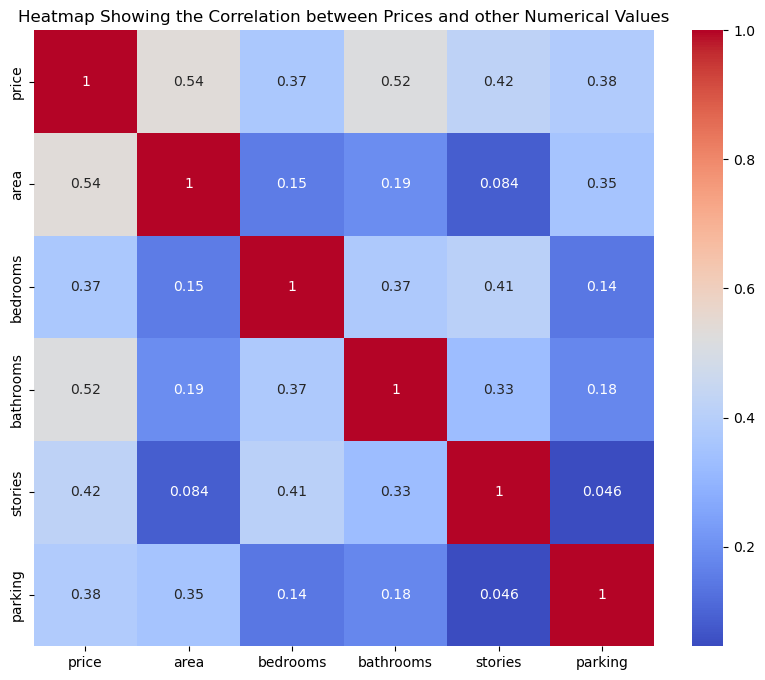

In [41]:
corr=df.corr(numeric_only=True)
fig=plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Showing the Correlation between Prices and other Numerical Values');

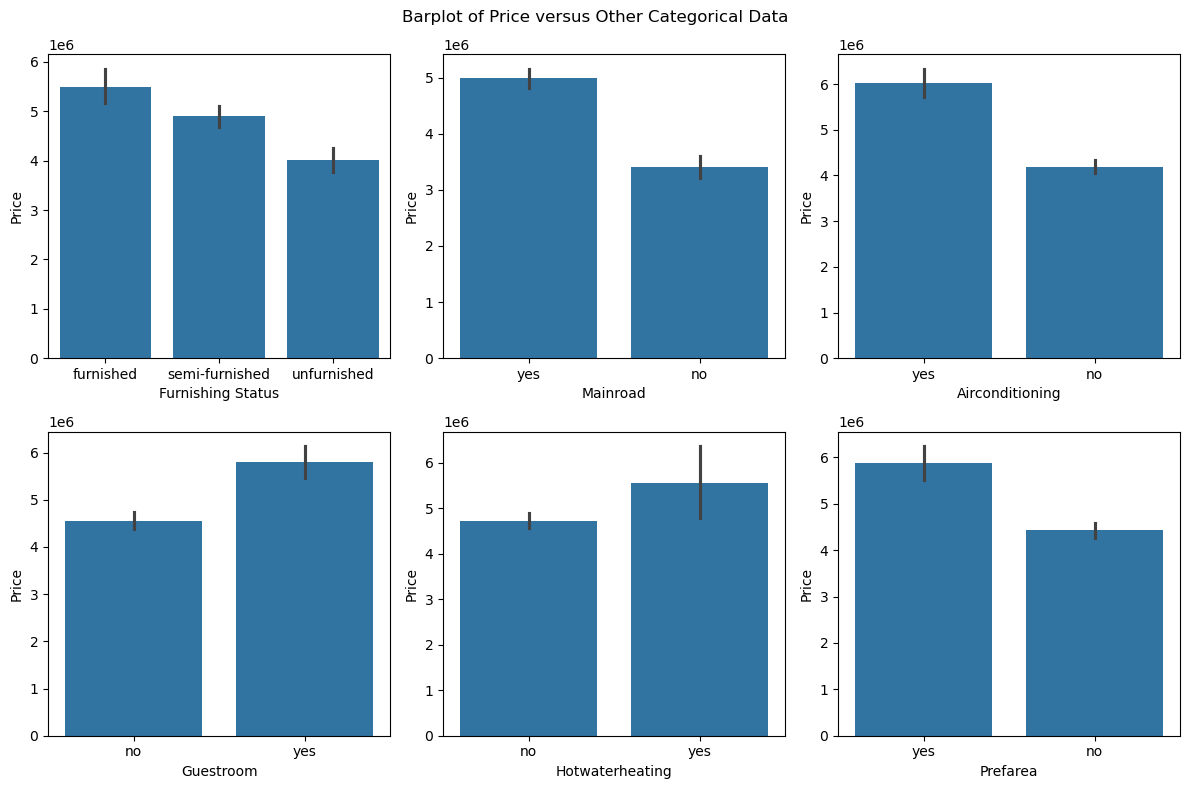

In [81]:
#relationship between the categorical data
fig=plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
sns.barplot(x=df['furnishingstatus'], y= df['price'], data =df)
plt.xlabel('Furnishing Status')
plt.ylabel('Price')

plt.subplot(2,3,2)
sns.barplot(x=df['mainroad'], y= df['price'], data=df)
plt.xlabel('Mainroad')
plt.ylabel('Price')


plt.subplot(2,3,3)
sns.barplot(x=df['airconditioning'], y= df['price'], data=df)
plt.xlabel('Airconditioning')
plt.ylabel('Price')

plt.subplot(2,3,4)
sns.barplot(x=df['guestroom'], y= df['price'], data=df)
plt.xlabel('Guestroom')
plt.ylabel('Price')

plt.subplot(2,3,5)
sns.barplot(x=df['hotwaterheating'], y= df['price'], data=df)
plt.xlabel('Hotwaterheating')
plt.ylabel('Price')

plt.subplot(2,3,6)
sns.barplot(x=df['prefarea'], y= df['price'], data=df)
plt.xlabel('Prefarea')
plt.ylabel('Price')

fig.suptitle('Barplot of Price versus Other Categorical Data')
plt.tight_layout()
plt.show()



## THIRD WEEK ASSIGNMENT

### Probability and Statistical Analysis 

In [56]:
#Statistical Analysis
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

### Descriptive Statistics

In [57]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Distributive Analysis

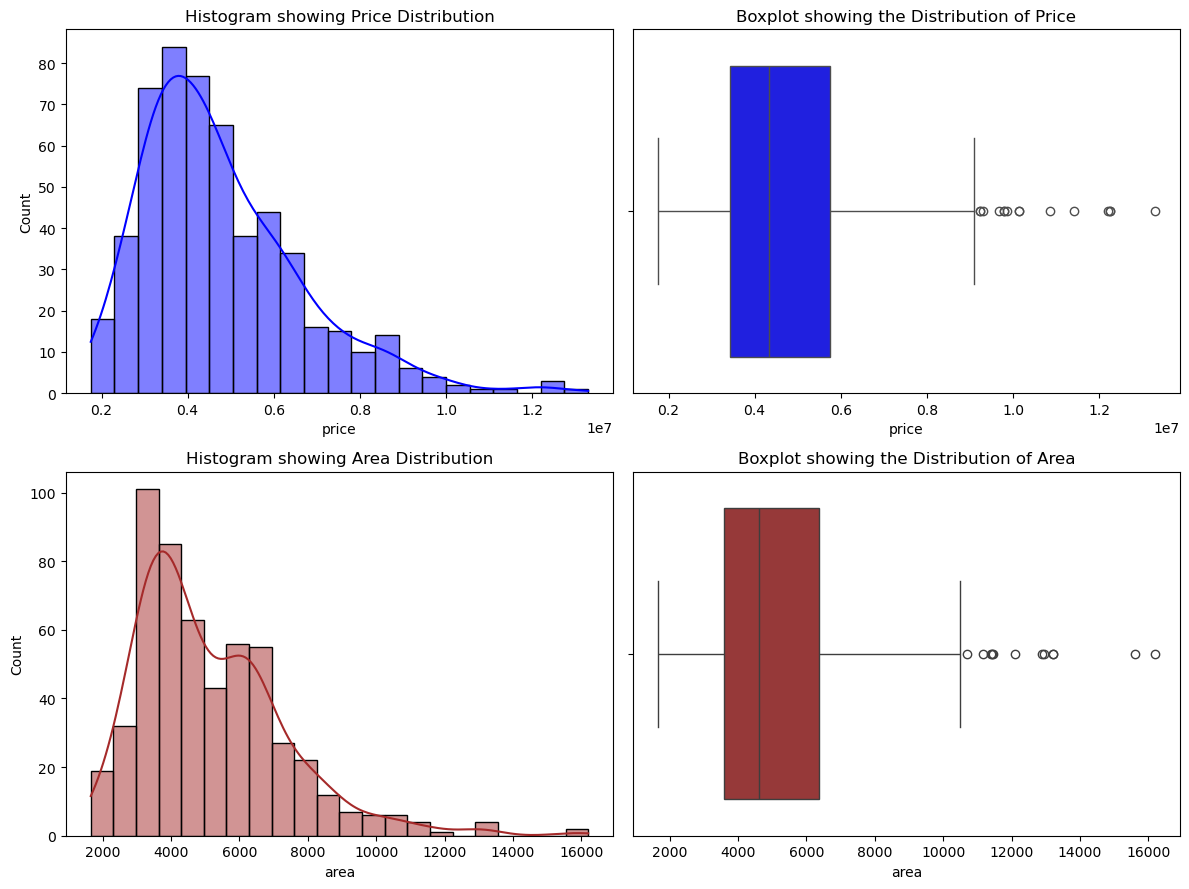

In [73]:
fig=plt.figure(figsize=(12,9))

plt.subplot(2,2,1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Histogram showing Price Distribution')

plt.subplot(2,2,2)
sns.boxplot(df['price'], orient='y', color='blue')
plt.title('Boxplot showing the Distribution of Price')

plt.subplot(2,2,3)
sns.histplot(df['area'], kde=True, color='brown')
plt.title('Histogram showing Area Distribution')

plt.subplot(2,2,4)
sns.boxplot(df['area'], orient='y', color='brown')
plt.title('Boxplot showing the Distribution of Area')
plt.tight_layout()

plt.show()

In [74]:
#Both the histogram and the boxplot of the price and area show that the data are right skewed, signifying
#that the data are more concentrated on the lower side of the price and area. We can also interprete it 
#that the data are not normally distributed. The nature of this data will affect our predictive model, if standardization is not done. 

### Correlative Analysis

Text(0.5, 1.0, 'Heatmap showing the Correlation between the Numerical Data')

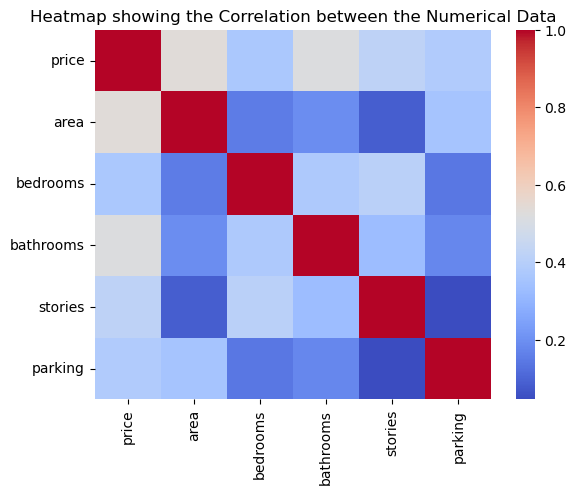

In [75]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Heatmap showing the Correlation between the Numerical Data')

In [76]:
corr['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

In [77]:
#The correlation of price to the other variable above shows that area has the stongest positive correlation followed by bathrooms, stories, parking and bedroom has the lowest positive correlation of 0.36


### Hypothetis Testing(T_Test for categorical values of 2)

In [79]:
ac_yes=df[df['airconditioning']=='yes']['price']
ac_no=df[df['airconditioning']=='no']['price']
t_stats, p_values= stats.ttest_ind(ac_yes,ac_no)
print('t_statistics', t_stats)
print('P_values', p_values)

t_statistics 11.839033782035843
P_values 6.310969853530074e-29


In [80]:
#The p-value obtained (6.31 × 10⁻²⁹) is significantly less than 0.05, indicating strong statistical evidence to reject the null hypothesis. This suggests that there is a statistically significant difference in house prices between homes with air conditioning and those without. Therefore, air conditioning appears to be an important feature influencing house prices in the dataset.

### Hypothetis Testing(T_Test for categorical values of 3)

In [82]:
unfurnished=df[df['furnishingstatus']=='unfurnished']['price']
semi=df[df['furnishingstatus']=='semi-furnished']['price']
furnished=df[df['furnishingstatus']=='furnished']['price']

f_stats, p_values=stats.f_oneway(unfurnished, semi, furnished)
print('F_statistics', f_stats)
print('P_Values', p_values)

F_statistics 28.27206844716457
P_Values 2.0928668857953132e-12


In [83]:
#The ANOVA test produced an F-statistic of 28.27 and a p-value of 2.09 × 10⁻¹², which is far below the 0.05 significance level. This indicates strong statistical evidence to reject the null hypothesis. Therefore, we conclude that furnishing status has a statistically significant effect on house prices. This suggests that furnished, semi-furnished, and unfurnished properties differ significantly in their average market value.